# Gaussian Processes

## Real-World Scenario: Predicting Enzyme Activity Across Conditions

In whole cell modeling, we measure **enzyme activity** (e.g., reaction rate of a metabolic enzyme) at a handful of experimental conditions — temperature, pH, substrate concentration — and want to predict the activity at *unmeasured* conditions. We don't know the functional form of the relationship, but we believe it's **smooth**: nearby conditions should produce similar enzyme activities.

A **Gaussian process** (GP) gives us exactly this: a principled, non-parametric way to place a probability distribution *over functions* and update it with data. Two ideas make GPs tick:

1. **The values of the function at any finite set of inputs are jointly Gaussian.** We never work with "the whole function" at once — we only ever look at finitely many inputs, and the GP says those function values follow a multivariate normal distribution.

2. **The kernel determines the correlation between function values.** If two inputs $\mathbf{x}$ and $\mathbf{x}'$ are "similar" according to the kernel $\kappa(\mathbf{x}, \mathbf{x}')$, then the function values $f(\mathbf{x})$ and $f(\mathbf{x}')$ are highly correlated — and therefore likely to be close.

This notebook builds intuition for both ideas from the ground up, then develops the full GP regression framework from Chapter 17.2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from scipy.linalg import cho_factor, cho_solve
from scipy.optimize import minimize

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## Key Formulas from PML Chapter 17.2

**GP definition** — a distribution over functions $f : \mathcal{X} \to \mathbb{R}$ such that for any finite set of inputs $\{x_1, \dots, x_M\}$:

$$\mathbf{f} = [f(x_1), \dots, f(x_M)]^\top \sim \mathcal{N}(\boldsymbol{\mu}, \mathbf{K})$$

where $\mu_i = m(x_i)$ is the mean function and $K_{ij} = \kappa(x_i, x_j)$ is the kernel.

**RBF (squared exponential) kernel** (Eq. 13.13):

$$\kappa(x, x') = \sigma_f^2 \exp\!\left(-\frac{\|x - x'\|^2}{2\ell^2}\right)$$

where $\sigma_f^2$ is the signal variance and $\ell$ is the length scale.

**Noise-free posterior** (Eqs. 17.28–17.30):

$$p(\mathbf{f}_* \mid \mathbf{X}_*, \mathcal{D}) = \mathcal{N}(\mathbf{f}_* \mid \boldsymbol{\mu}_*, \boldsymbol{\Sigma}_*)$$

$$\boldsymbol{\mu}_* = m(\mathbf{X}_*) + \mathbf{K}_{X,*}^\top \mathbf{K}_{X,X}^{-1}(\mathbf{f}_X - m(\mathbf{X}))$$

$$\boldsymbol{\Sigma}_* = \mathbf{K}_{*,*} - \mathbf{K}_{X,*}^\top \mathbf{K}_{X,X}^{-1} \mathbf{K}_{X,*}$$

**Noisy posterior** with $y_n = f(x_n) + \epsilon_n$, $\epsilon_n \sim \mathcal{N}(0, \sigma_y^2)$ (Eqs. 17.34–17.36):

$$\boldsymbol{\mu}_{*|X} = m(\mathbf{X}_*) + \mathbf{K}_{X,*}^\top \mathbf{K}_\sigma^{-1}(\mathbf{y} - m(\mathbf{X}))$$

$$\boldsymbol{\Sigma}_{*|X} = \mathbf{K}_{*,*} - \mathbf{K}_{X,*}^\top \mathbf{K}_\sigma^{-1} \mathbf{K}_{X,*}$$

where $\mathbf{K}_\sigma = \mathbf{K}_{X,X} + \sigma_y^2 \mathbf{I}_N$.

**Log marginal likelihood** (Eq. 17.52):

$$\log p(\mathbf{y} \mid \mathbf{X}, \boldsymbol{\theta}) = -\tfrac{1}{2}\mathbf{y}^\top \mathbf{K}_\sigma^{-1}\mathbf{y} - \tfrac{1}{2}\log|\mathbf{K}_\sigma| - \tfrac{N}{2}\log(2\pi)$$

## 1. What Does "Function Values Are Jointly Gaussian" Mean?

A function $f : \mathbb{R} \to \mathbb{R}$ maps every input $x$ to an output $f(x)$. There are infinitely many inputs, so we can never write down the "whole function" at once. A GP sidesteps this by making a **finite-dimensional promise**:

> Pick *any* finite collection of inputs $x_1, \dots, x_M$. The corresponding outputs $f(x_1), \dots, f(x_M)$ follow a multivariate Gaussian.

This is the *only* assumption. It doesn't say anything about the form of $f$ — no polynomial degree, no number of hidden units. It just says: **whatever subset of the function you look at, it's Gaussian**.

### Concrete example with M = 2

Suppose we pick two temperatures $x_1 = 30°C$ and $x_2 = 35°C$ and ask: what is the enzyme activity $f(30)$ and $f(35)$? The GP says:

$$\begin{pmatrix} f(30) \\ f(35) \end{pmatrix} \sim \mathcal{N}\left(\begin{pmatrix} \mu_1 \\ \mu_2 \end{pmatrix}, \begin{pmatrix} \kappa(30,30) & \kappa(30,35) \\ \kappa(35,30) & \kappa(35,35) \end{pmatrix}\right)$$

The diagonal entries $\kappa(x, x)$ control how much the function varies at each point. The off-diagonal entry $\kappa(30, 35)$ controls **how correlated** the two function values are. This is where the kernel comes in — but first, let's *see* the joint Gaussian.

In [2]:
def rbf_kernel(x1, x2, length_scale=1.0, signal_var=1.0):
    """Squared exponential (RBF) kernel: κ(x, x') = σ²_f exp(-||x-x'||² / (2ℓ²))"""
    x1 = np.atleast_2d(x1)
    x2 = np.atleast_2d(x2)
    sq_dist = np.sum(x1**2, axis=1, keepdims=True) + np.sum(x2**2, axis=1) - 2 * x1 @ x2.T
    return signal_var * np.exp(-0.5 * sq_dist / length_scale**2)

# --- Pick two inputs and visualize their joint Gaussian ---
x1, x2 = 30.0, 35.0
X_pair = np.array([[x1], [x2]])
ell = 5.0  # length scale in °C

K = rbf_kernel(X_pair, X_pair, length_scale=ell)
mu = np.array([0.0, 0.0])

print(f"Inputs: x₁ = {x1}°C, x₂ = {x2}°C")
print(f"Length scale ℓ = {ell}°C")
print(f"\nCovariance matrix (the 2×2 Gram matrix):")
print(f"  K = [[{K[0,0]:.4f}, {K[0,1]:.4f}],")
print(f"       [{K[1,0]:.4f}, {K[1,1]:.4f}]]")
print(f"\nCorrelation: ρ = {K[0,1] / np.sqrt(K[0,0] * K[1,1]):.4f}")
print(f"  → f(30) and f(35) are highly correlated because 30 and 35 are close relative to ℓ=5")

Inputs: x₁ = 30.0°C, x₂ = 35.0°C
Length scale ℓ = 5.0°C

Covariance matrix (the 2×2 Gram matrix):
  K = [[1.0000, 0.6065],
       [0.6065, 1.0000]]

Correlation: ρ = 0.6065
  → f(30) and f(35) are highly correlated because 30 and 35 are close relative to ℓ=5


In [3]:
# Step-by-step: how rbf_kernel computes pairwise distances via broadcasting
# x1 and x2 do NOT need the same number of rows — that's the whole point.

X_a = np.array([[30.0], [35.0], [40.0]])   # (3, 1) — 3 training points
X_b = np.array([[32.0], [38.0]])            # (2, 1) — 2 test points

print("X_a shape:", X_a.shape)
print("X_b shape:", X_b.shape)

# Step 1: squared norms along rows
a = np.sum(X_a**2, axis=1, keepdims=True)   # (3, 1)
b = np.sum(X_b**2, axis=1)                  # (2,)
print(f"\n‖X_a‖² (shape {a.shape}):\n{a}")
print(f"\n‖X_b‖² (shape {b.shape}):\n{b}")

# Step 2: broadcasting (3,1) + (2,) → (3,2)  — all pairwise sums
print(f"\n‖X_a‖² + ‖X_b‖² via broadcasting → shape {(a + b).shape}:")
print(a + b)

# Step 3: cross term  (3,1) @ (1,2) → (3,2)
cross = 2 * X_a @ X_b.T
print(f"\n2·X_a·X_bᵀ (shape {cross.shape}):\n{cross}")

# Step 4: squared distances  ||X_a_i - X_b_j||²
sq_dist = a + b - cross
print(f"\nsq_dist = ‖X_a‖² + ‖X_b‖² − 2·X_a·X_bᵀ:\n{sq_dist}")

# Verify against explicit pairwise differences
print("\nVerification (brute force):")
for i in range(len(X_a)):
    for j in range(len(X_b)):
        print(f"  ‖{X_a[i,0]} − {X_b[j,0]}‖² = {(X_a[i,0] - X_b[j,0])**2:.1f}  (matrix: {sq_dist[i,j]:.1f})")

# Final kernel matrix
K_demo = rbf_kernel(X_a, X_b, length_scale=5.0)
print(f"\nRBF kernel matrix (3×2) with ℓ=5:\n{np.round(K_demo, 4)}")

X_a shape: (3, 1)
X_b shape: (2, 1)

‖X_a‖² (shape (3, 1)):
[[ 900.]
 [1225.]
 [1600.]]

‖X_b‖² (shape (2,)):
[1024. 1444.]

‖X_a‖² + ‖X_b‖² via broadcasting → shape (3, 2):
[[1924. 2344.]
 [2249. 2669.]
 [2624. 3044.]]

2·X_a·X_bᵀ (shape (3, 2)):
[[1920. 2280.]
 [2240. 2660.]
 [2560. 3040.]]

sq_dist = ‖X_a‖² + ‖X_b‖² − 2·X_a·X_bᵀ:
[[ 4. 64.]
 [ 9.  9.]
 [64.  4.]]

Verification (brute force):
  ‖30.0 − 32.0‖² = 4.0  (matrix: 4.0)
  ‖30.0 − 38.0‖² = 64.0  (matrix: 64.0)
  ‖35.0 − 32.0‖² = 9.0  (matrix: 9.0)
  ‖35.0 − 38.0‖² = 9.0  (matrix: 9.0)
  ‖40.0 − 32.0‖² = 64.0  (matrix: 64.0)
  ‖40.0 − 38.0‖² = 4.0  (matrix: 4.0)

RBF kernel matrix (3×2) with ℓ=5:
[[0.9231 0.278 ]
 [0.8353 0.8353]
 [0.278  0.9231]]


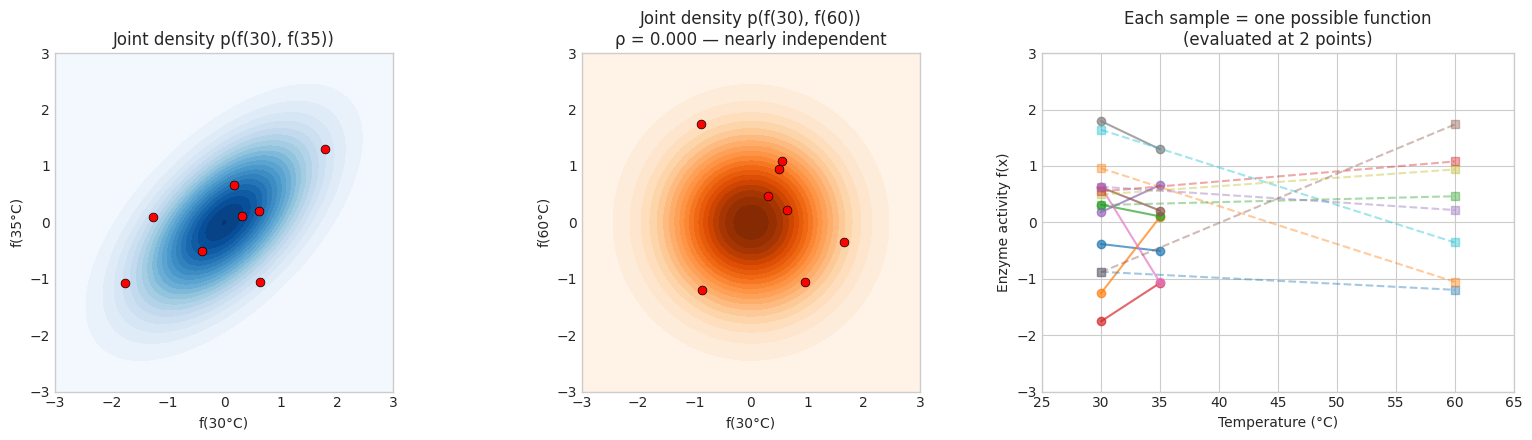

In [4]:
# Visualize the 2D joint Gaussian and its samples
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Joint density contour
from scipy.stats import multivariate_normal
f1_grid = np.linspace(-3, 3, 200)
f2_grid = np.linspace(-3, 3, 200)
F1, F2 = np.meshgrid(f1_grid, f2_grid)
pos = np.dstack((F1, F2))
rv = multivariate_normal(mu, K)
axes[0].contourf(F1, F2, rv.pdf(pos), levels=20, cmap='Blues')
axes[0].set_xlabel('f(30°C)')
axes[0].set_ylabel('f(35°C)')
axes[0].set_title('Joint density p(f(30), f(35))')
axes[0].set_aspect('equal')

# Draw samples from the joint
samples = np.random.multivariate_normal(mu, K, size=8)
axes[0].scatter(samples[:, 0], samples[:, 1], c='red', s=40, zorder=5, edgecolors='k', linewidth=0.5)

# (b) Same thing but with distant points (low correlation)
x1_far, x2_far = 30.0, 60.0
X_far = np.array([[x1_far], [x2_far]])
K_far = rbf_kernel(X_far, X_far, length_scale=ell)
rv_far = multivariate_normal(mu, K_far)
axes[1].contourf(F1, F2, rv_far.pdf(pos), levels=20, cmap='Oranges')
samples_far = np.random.multivariate_normal(mu, K_far, size=8)
axes[1].scatter(samples_far[:, 0], samples_far[:, 1], c='red', s=40, zorder=5, edgecolors='k', linewidth=0.5)
axes[1].set_xlabel('f(30°C)')
axes[1].set_ylabel('f(60°C)')
axes[1].set_title(f'Joint density p(f(30), f(60))\nρ = {K_far[0,1]:.3f} — nearly independent')
axes[1].set_aspect('equal')

# (c) Interpretation: what each sample means as a "function"
axes[2].set_xlim(25, 65)
axes[2].set_ylim(-3, 3)
for s in samples:
    axes[2].plot([30, 35], s, 'o-', alpha=0.7, markersize=6)
for s in samples_far:
    axes[2].plot([30, 60], s, 's--', alpha=0.4, markersize=6)
axes[2].set_xlabel('Temperature (°C)')
axes[2].set_ylabel('Enzyme activity f(x)')
axes[2].set_title('Each sample = one possible function\n(evaluated at 2 points)')

plt.tight_layout()
plt.show()

In [5]:
samples

array([[-0.38385358, -0.50650724],
       [-1.25602789,  0.09504526],
       [ 0.31371106,  0.10600919],
       [-1.7557646 , -1.0749766 ],
       [ 0.18011542,  0.66141808],
       [ 0.62191185,  0.20876502],
       [ 0.63177243, -1.06549014],
       [ 1.79536024,  1.29655742]])

### From 2 points to M points: a function emerges

With $M = 2$ points we just get a line segment. But the GP promise holds for *any* $M$. If we evaluate the GP at 200 densely-spaced inputs, we get a 200-dimensional Gaussian — and each sample from it looks like a **smooth curve**. The curve is smooth because nearby inputs have high kernel correlation, so their function values can't jump wildly.

This is how a GP "generates functions": it doesn't have a formula for $f$. It just says $[f(x_1), \dots, f(x_{200})]$ is a single draw from a 200-dimensional Gaussian whose covariance is the $200 \times 200$ kernel matrix.

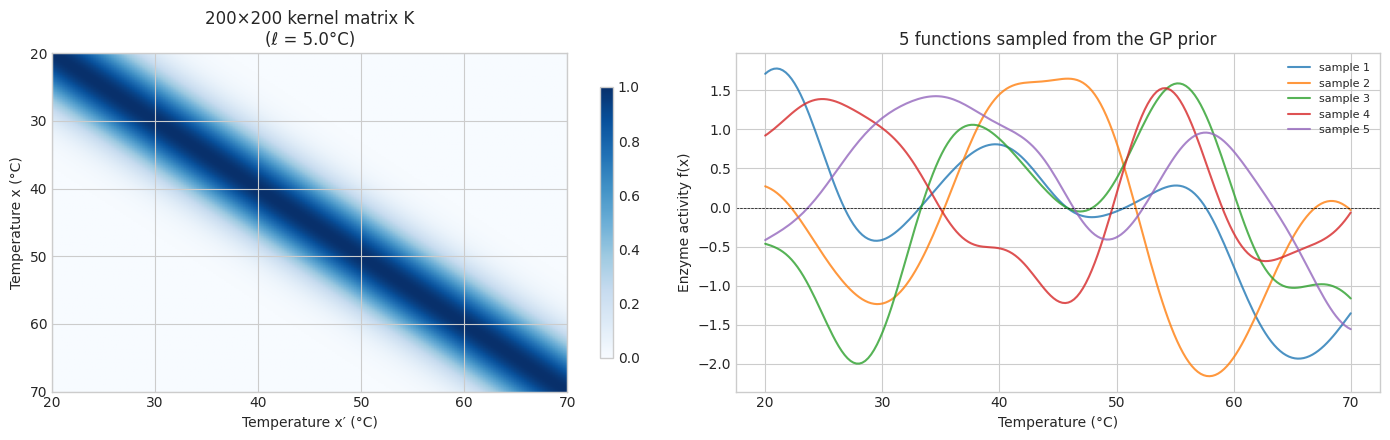

In [6]:
# From 2 points to 200: samples look like smooth functions
X_dense = np.linspace(20, 70, 200).reshape(-1, 1)  # 200 temperatures  shape : (200, 1)
K_dense = rbf_kernel(X_dense, X_dense, length_scale=ell)
K_dense += 1e-8 * np.eye(len(X_dense))  # numerical stability

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) The 200×200 kernel matrix
im = axes[0].imshow(K_dense, extent=[20, 70, 70, 20], cmap='Blues', aspect='auto')
axes[0].set_xlabel('Temperature x′ (°C)')
axes[0].set_ylabel('Temperature x (°C)')
axes[0].set_title(f'200×200 kernel matrix K\n(ℓ = {ell}°C)')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# (b) Samples from the 200-dim Gaussian = smooth functions
samples_dense = np.random.multivariate_normal(np.zeros(200), K_dense, size=5)
for i, s in enumerate(samples_dense):
    axes[1].plot(X_dense, s, alpha=0.8, label=f'sample {i+1}')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Enzyme activity f(x)')
axes[1].set_title('5 functions sampled from the GP prior')
axes[1].legend(fontsize=8)
axes[1].axhline(0, color='k', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

In [7]:
samples_dense.shape

(5, 200)

## 2. How the Kernel Determines Correlation Between Function Values

The kernel $\kappa(x, x')$ is the **covariance** between $f(x)$ and $f(x')$:

$$\text{Cov}[f(x),\, f(x')] = \kappa(x, x')$$

For the RBF kernel $\kappa(x, x') = \sigma_f^2 \exp\!\left(-\frac{(x - x')^2}{2\ell^2}\right)$:

| Situation | Kernel value | Effect |
|-----------|-------------|--------|
| $x = x'$ | $\sigma_f^2$ (maximum) | Perfect correlation — same point, same value |
| $\|x - x'\| \ll \ell$ | Close to $\sigma_f^2$ | High correlation — nearby inputs have similar $f$ values |
| $\|x - x'\| \gg \ell$ | Close to $0$ | Near independence — distant inputs are free to differ |

The **length scale** $\ell$ controls how far "nearby" extends. A small $\ell$ means only very close inputs are correlated, producing **wiggly** functions. A large $\ell$ means far-apart inputs are still correlated, producing **smooth** functions.

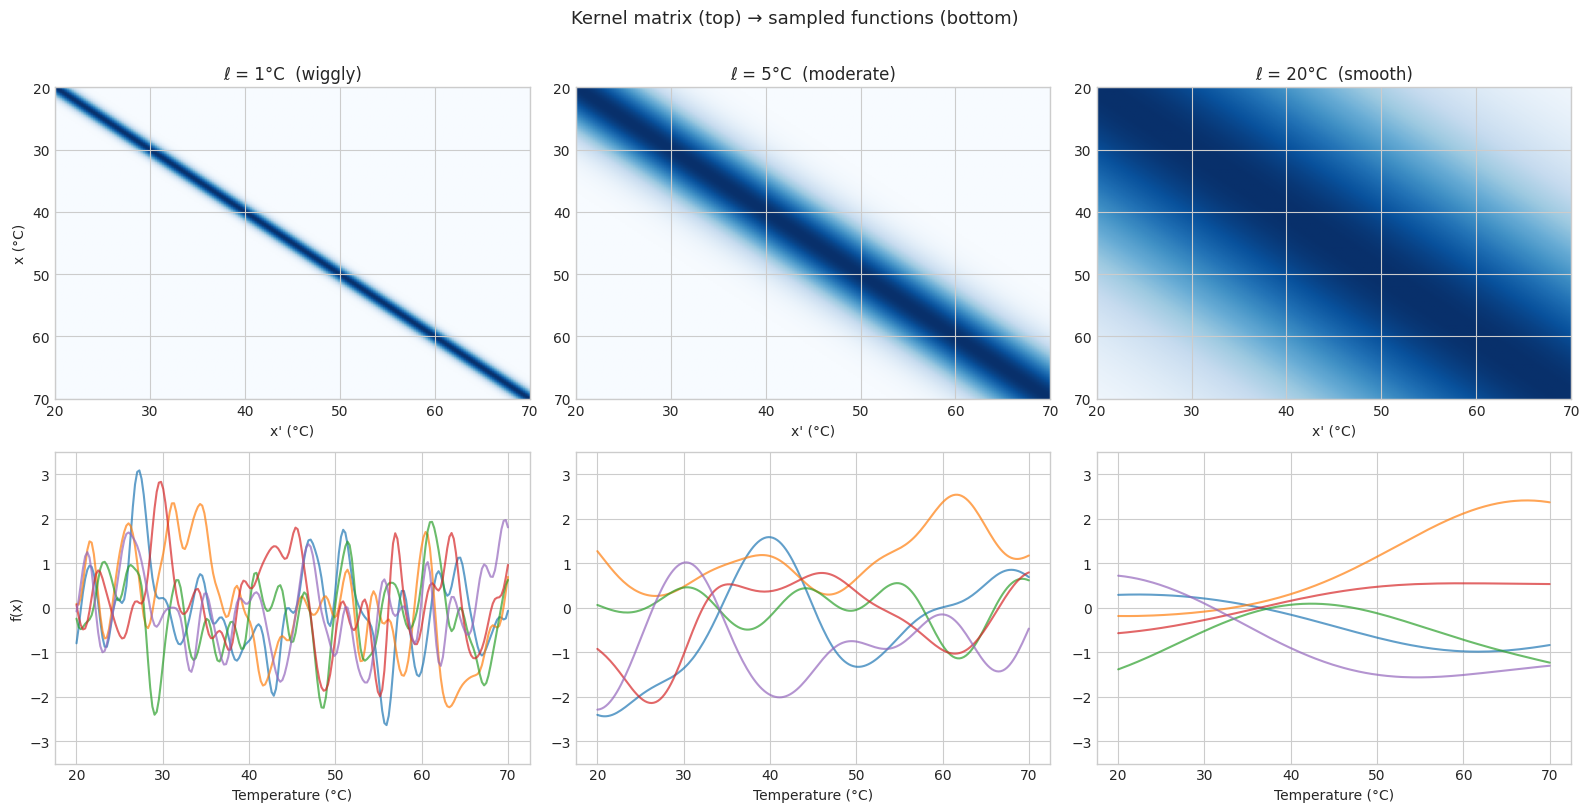

In [8]:
# Show how the length scale shapes the functions
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
length_scales = [1.0, 5.0, 20.0]

for col, ell_i in enumerate(length_scales):
    K_i = rbf_kernel(X_dense, X_dense, length_scale=ell_i) + 1e-8 * np.eye(200)

    # Top row: kernel matrix
    axes[0, col].imshow(K_i, extent=[20, 70, 70, 20], cmap='Blues', aspect='auto', vmin=0, vmax=1)
    axes[0, col].set_title(f'ℓ = {ell_i}°C')
    axes[0, col].set_xlabel("x' (°C)")
    if col == 0:
        axes[0, col].set_ylabel('x (°C)')

    # Bottom row: sampled functions
    samples_i = np.random.multivariate_normal(np.zeros(200), K_i, size=5)
    for s in samples_i:
        axes[1, col].plot(X_dense, s, alpha=0.7)
    axes[1, col].set_xlabel('Temperature (°C)')
    axes[1, col].set_ylim(-3.5, 3.5)
    if col == 0:
        axes[1, col].set_ylabel('f(x)')

axes[0, 0].set_title('ℓ = 1°C  (wiggly)')
axes[0, 1].set_title('ℓ = 5°C  (moderate)')
axes[0, 2].set_title('ℓ = 20°C  (smooth)')

plt.suptitle('Kernel matrix (top) → sampled functions (bottom)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Putting both ideas together

The two ideas are really **one mechanism**:

1. We pick a finite grid of inputs $x_1, \dots, x_M$.
2. The kernel builds the $M \times M$ covariance matrix $\mathbf{K}$.
3. We sample $\mathbf{f} \sim \mathcal{N}(\mathbf{0}, \mathbf{K})$ — a single draw from an $M$-dimensional Gaussian.
4. Plotting $\mathbf{f}$ against the grid gives a smooth curve.

The kernel **is** the prior belief about which functions are plausible. A short length scale says "I expect the enzyme activity to change rapidly with temperature." A long length scale says "I expect it to be smooth." The GP prior encodes this belief *entirely* through the correlations in the kernel matrix.

## 3. GP Regression: Noise-Free Observations (§17.2.1)

Now suppose we actually measure the enzyme activity at a few temperatures. With noise-free observations $y_n = f(x_n)$, conditioning the joint Gaussian on the observed values gives the posterior:

$$\boldsymbol{\mu}_* = \mathbf{K}_{X,*}^\top \mathbf{K}_{X,X}^{-1} \mathbf{f}_X, \qquad \boldsymbol{\Sigma}_* = \mathbf{K}_{*,*} - \mathbf{K}_{X,*}^\top \mathbf{K}_{X,X}^{-1} \mathbf{K}_{X,*}$$

This is just **Gaussian conditioning** (Chapter 3.2.3) — the same formula we used for MVN marginals and conditionals. The GP perfectly **interpolates** the data: uncertainty drops to zero at observed points.

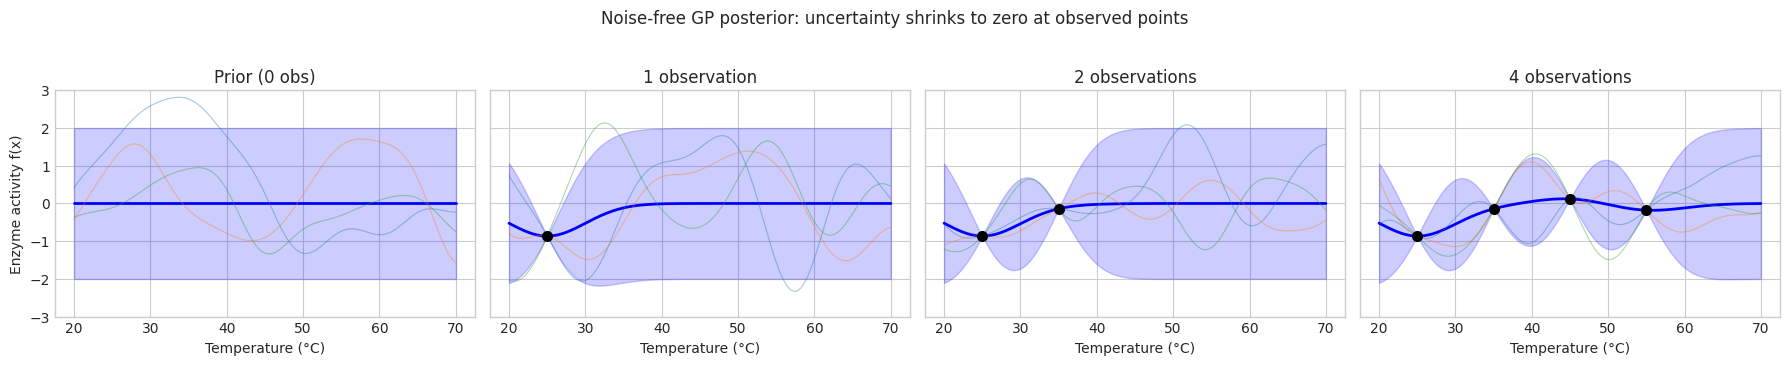

In [ ]:
def gp_posterior(X_train, y_train, X_test, length_scale, signal_var=1.0, noise_var=0.0):
    """Compute GP posterior mean and variance at test points."""
    K_XX = rbf_kernel(X_train, X_train, length_scale, signal_var) + noise_var * np.eye(len(X_train))
    K_Xs = rbf_kernel(X_train, X_test, length_scale, signal_var)
    K_ss = rbf_kernel(X_test, X_test, length_scale, signal_var)

    # Solve via Cholesky for numerical stability (Eq. 17.47-17.48)
    L, low = cho_factor(K_XX)
    alpha = cho_solve((L, low), y_train)
    mu_post = K_Xs.T @ alpha

    v = cho_solve((L, low), K_Xs)
    cov_post = K_ss - K_Xs.T @ v
    var_post = np.diag(cov_post)

    return mu_post.ravel(), var_post, cov_post

# --- Synthetic enzyme data (true function unknown to the GP) ---
def true_enzyme_activity(x):
    """Fake but realistic enzyme activity curve (arbitrary units)."""
    return 0.5 * np.sin(0.15 * (x - 30)) + 0.3 * np.cos(0.08 * x) + 0.02 * (x - 45)

# Noise-free observations at 4 temperatures
X_obs = np.array([[25], [35], [45], [55]])
y_obs = true_enzyme_activity(X_obs).ravel()

X_test = np.linspace(20, 70, 200).reshape(-1, 1)
ell_fit = 5.0

mu, var, cov = gp_posterior(X_obs, y_obs, X_test, length_scale=ell_fit, noise_var=0.0)
std = np.sqrt(np.clip(var, 0, None))

# Visualize progressive conditioning (1, 2, 3, 4 observations)
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5), sharey=True)
titles = ['Prior (0 obs)', '1 observation', '2 observations', '4 observations']
n_obs_list = [0, 1, 2, 4]

for ax, n_obs, title in zip(axes, n_obs_list, titles):
    if n_obs == 0:
        mu_i = np.zeros(200)
        K_i = rbf_kernel(X_test, X_test, length_scale=ell_fit) + 1e-8 * np.eye(200)
        std_i = np.ones(200)
        cov_i = K_i
    else:
        mu_i, var_i, cov_i = gp_posterior(X_obs[:n_obs], y_obs[:n_obs], X_test,
                                           length_scale=ell_fit, noise_var=1e-10)
        std_i = np.sqrt(np.clip(var_i, 0, None))

    # Plot mean and confidence band
    ax.plot(X_test, mu_i, 'b-', linewidth=2)
    ax.fill_between(X_test.ravel(), mu_i - 2*std_i, mu_i + 2*std_i, alpha=0.2, color='blue') 

    # Sample posterior functions
    samples_post = np.random.multivariate_normal(mu_i.ravel(), cov_i + 1e-8*np.eye(200), size=3)
    for s in samples_post:
        ax.plot(X_test, s, alpha=0.4, linewidth=0.8)

    if n_obs > 0:
        ax.plot(X_obs[:n_obs], y_obs[:n_obs], 'ko', markersize=7, zorder=5)

    ax.set_xlabel('Temperature (°C)')
    ax.set_title(title)
    ax.set_ylim(-3, 3)

axes[0].set_ylabel('Enzyme activity f(x)')
plt.suptitle('Noise-free GP posterior: uncertainty shrinks to zero at observed points', y=1.03, fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
mu.shape

(200,)

## 4. GP Regression: Noisy Observations (§17.2.2)

In practice, measurements are noisy: $y_n = f(x_n) + \epsilon_n$ where $\epsilon_n \sim \mathcal{N}(0, \sigma_y^2)$. The noise adds $\sigma_y^2$ to the diagonal of the training covariance (Eq. 17.32):

$$\mathbf{K}_\sigma = \mathbf{K}_{X,X} + \sigma_y^2 \mathbf{I}_N$$

The posterior no longer interpolates — the mean passes *near* the data but not exactly through it, and uncertainty at observed points stays nonzero.

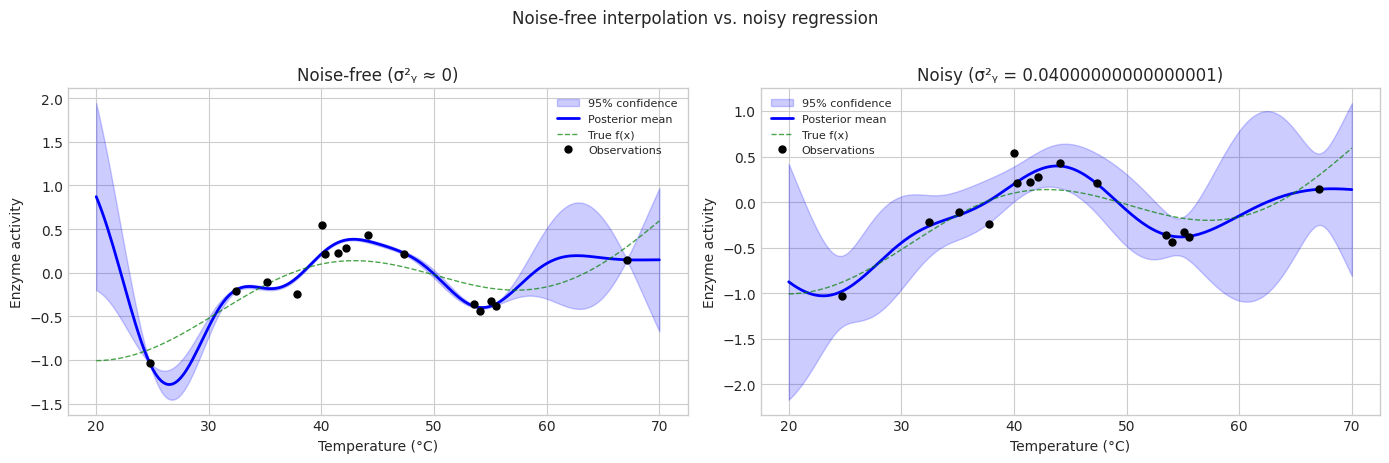

In [21]:
# Generate more realistic data: 15 noisy enzyme measurements
np.random.seed(123)
N_train = 15
X_train = np.sort(np.random.uniform(22, 68, N_train)).reshape(-1, 1)
sigma_y = 0.2
y_train = true_enzyme_activity(X_train).ravel() + sigma_y * np.random.randn(N_train)

# Compare noise-free vs noisy posterior
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ell_fit = 6.0

for ax, noise, title in zip(axes, [1e-4, sigma_y**2],
                              ['Noise-free (σ²ᵧ ≈ 0)', f'Noisy (σ²ᵧ = {sigma_y**2})']):
    mu_i, var_i, cov_i = gp_posterior(X_train, y_train, X_test,
                                       length_scale=ell_fit, noise_var=noise)
    std_i = np.sqrt(np.clip(var_i, 0, None))

    ax.fill_between(X_test.ravel(), mu_i - 2*std_i, mu_i + 2*std_i,
                     alpha=0.2, color='blue', label='95% confidence')
    ax.plot(X_test, mu_i, 'b-', linewidth=2, label='Posterior mean')
    ax.plot(X_test, true_enzyme_activity(X_test), 'g--', linewidth=1, alpha=0.7, label='True f(x)')
    ax.plot(X_train, y_train, 'ko', markersize=5, label='Observations')
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Enzyme activity')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Noise-free interpolation vs. noisy regression', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

### Reading the two charts carefully

**The black dots are noisy in both plots.** They are generated once as

```python
y_train = true_enzyme_activity(X_train) + sigma_y * np.random.randn(N_train)
```

so each dot sits *near* the true green curve, not on it. "Noise-free" on the left refers to **how the GP treats them**, not how they were generated.

**Left chart — "noise-free" (σ²ᵧ ≈ 0).** We tell the GP: *"assume these observations are exact"*. The posterior is then forced to (nearly) interpolate through each noisy dot, dragging the mean away from the true function. This is the classic illustration of what goes wrong when you lie to the GP about the noise level — it faithfully reproduces the lie.

**Right chart — noisy (σ²ᵧ = sigma_y²).** We tell the GP the truth about the noise. The posterior mean stays smooth and close to the green true curve; each dot contributes information but is not treated as ground truth.

### Why doesn't the left mean pass *exactly* through the points?

The code uses `noise_var=1e-6` (a small jitter) rather than `noise_var=0`. Strict interpolation with `noise_var=0` is numerically dangerous: when training points are close relative to the length scale, the kernel matrix $\mathbf{K}_{XX}$ is nearly singular and Cholesky returns garbage (often a near-flat posterior mean).

The posterior mean is

$$\boldsymbol{\mu}_* = \mathbf{K}_{X,*}^\top (\mathbf{K}_{XX} + \sigma_y^2 \mathbf{I})^{-1} \mathbf{y}$$

and the $+\sigma_y^2 \mathbf{I}$ term acts as a **ridge regularizer** — it pulls the mean slightly away from each $y_i$. Three regimes:

| `noise_var` | Behavior | Numerical stability |
|---|---|---|
| `0` | Exact interpolation | Singular, unstable |
| `1e-6` (jitter) | Nearly exact, tiny pull off each point | Stable |
| `sigma_y²` (true noise) | Honest smoothing, visible pull toward the true curve | Stable |

So on the left chart, a tight-but-not-perfect pass through the dots is correct. If the offset looks large, the length scale `ell_fit = 6.0` may be too big relative to the point spacing — shortening it lets the mean wiggle more tightly through each observation.

## 5. Weight Space vs. Function Space (§17.2.4)

GP regression is equivalent to Bayesian linear regression in a feature space defined by the kernel. If $f(\mathbf{x}) = \mathbf{w}^\top \boldsymbol{\phi}(\mathbf{x})$ with prior $\mathbf{w} \sim \mathcal{N}(\mathbf{0}, \boldsymbol{\Sigma}_w)$, then the kernel is:

$$\kappa(\mathbf{x}, \mathbf{x}') = \boldsymbol{\phi}(\mathbf{x})^\top \boldsymbol{\Sigma}_w \boldsymbol{\phi}(\mathbf{x}')$$

The **weight-space view** works with a $D$-dimensional weight vector. The **function-space view** (GP) works directly with the $N \times N$ kernel matrix. They give identical predictions (Eq. 17.44–17.46), but the GP view is more general — it works even when the feature map $\boldsymbol{\phi}$ is infinite-dimensional (as with the RBF kernel).

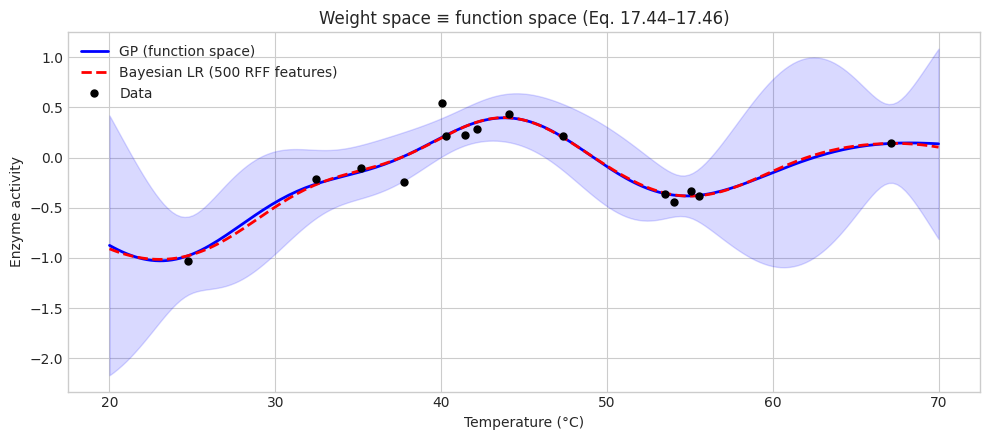

In [11]:
# Demonstrate equivalence: Bayesian linear regression with RBF features ≡ GP
# Use random Fourier features to approximate the RBF kernel (finite-dim approximation)
np.random.seed(42)

D_features = 500  # number of random Fourier features
ell_demo = 6.0

# Random Fourier features: φ(x) = sqrt(2/D) * cos(ωx + b) approximates RBF kernel
omega = np.random.randn(D_features) / ell_demo
b = np.random.uniform(0, 2*np.pi, D_features)

def rff_features(X, omega, b):
    return np.sqrt(2.0 / len(omega)) * np.cos(X @ omega.reshape(1, -1) + b)

Phi_train = rff_features(X_train, omega, b)  # N × D
Phi_test = rff_features(X_test, omega, b)     # M × D

# Bayesian linear regression: posterior p(w|D)
Sigma_w_inv = np.eye(D_features)  # prior precision (Σ_w = I)
A = (1/sigma_y**2) * Phi_train.T @ Phi_train + Sigma_w_inv
A_inv = np.linalg.inv(A)
w_post = (1/sigma_y**2) * A_inv @ Phi_train.T @ y_train

# Weight-space predictions
mu_weight = Phi_test @ w_post
var_weight = np.sum(Phi_test @ A_inv * Phi_test, axis=1)

# GP (function-space) predictions
mu_gp, var_gp, _ = gp_posterior(X_train, y_train, X_test,
                                 length_scale=ell_demo, noise_var=sigma_y**2)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(X_test, mu_gp, 'b-', linewidth=2, label='GP (function space)')
ax.plot(X_test, mu_weight, 'r--', linewidth=2, label=f'Bayesian LR ({D_features} RFF features)')
ax.fill_between(X_test.ravel(), mu_gp - 2*np.sqrt(np.clip(var_gp, 0, None)),
                 mu_gp + 2*np.sqrt(np.clip(var_gp, 0, None)), alpha=0.15, color='blue')
ax.plot(X_train, y_train, 'ko', markersize=5, label='Data')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Enzyme activity')
ax.set_title('Weight space ≡ function space (Eq. 17.44–17.46)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Estimating Kernel Hyperparameters (§17.2.6)

The kernel has free parameters $\boldsymbol{\theta} = (\ell, \sigma_f^2, \sigma_y^2)$ that strongly affect predictions. The GP framework provides a principled way to set them: **maximize the log marginal likelihood** (Eq. 17.52):

$$\log p(\mathbf{y} \mid \mathbf{X}, \boldsymbol{\theta}) = \underbrace{-\tfrac{1}{2}\mathbf{y}^\top \mathbf{K}_\sigma^{-1}\mathbf{y}}_{\text{data fit}} \underbrace{- \tfrac{1}{2}\log|\mathbf{K}_\sigma|}_{\text{complexity penalty}} - \tfrac{N}{2}\log(2\pi)$$

- **Data fit**: prefers kernels where the data is likely under the model
- **Complexity penalty**: penalizes overly flexible models (automatic Occam's razor)

This balances underfitting vs. overfitting *without* cross-validation.

In [12]:
def neg_log_marginal_likelihood(log_theta, X, y):
    """Negative log marginal likelihood (Eq. 17.52), parameterized in log-space."""
    ell = np.exp(np.clip(log_theta[0], -20, 20))
    sf2 = np.exp(np.clip(log_theta[1], -20, 20))
    sy2 = np.exp(np.clip(log_theta[2], -20, 20))

    K_sigma = rbf_kernel(X, X, length_scale=ell, signal_var=sf2) + sy2 * np.eye(len(X))
    L, low = cho_factor(K_sigma)
    alpha = cho_solve((L, low), y)

    # Eq. 17.49
    nll = 0.5 * y @ alpha + np.sum(np.log(np.diag(L))) + 0.5 * len(y) * np.log(2 * np.pi)
    return nll

# Optimize hyperparameters with multiple restarts (§17.2.6 warns about local minima)
best_nll = np.inf
best_theta = None
for _ in range(10):
    log_theta0 = np.random.randn(3) * 0.5
    res = minimize(neg_log_marginal_likelihood, log_theta0, args=(X_train, y_train), method='L-BFGS-B')
    if res.fun < best_nll:
        best_nll = res.fun
        best_theta = res.x

ell_opt, sf2_opt, sy2_opt = np.exp(best_theta)
print(f"Optimized hyperparameters:")
print(f"  Length scale  ℓ   = {ell_opt:.3f}°C")
print(f"  Signal var    σ²_f = {sf2_opt:.3f}")
print(f"  Noise var     σ²_y = {sy2_opt:.3f}")
print(f"  Neg. log ML       = {best_nll:.3f}")

Optimized hyperparameters:
  Length scale  ℓ   = 6.188°C
  Signal var    σ²_f = 0.224
  Noise var     σ²_y = 0.027
  Neg. log ML       = 2.507


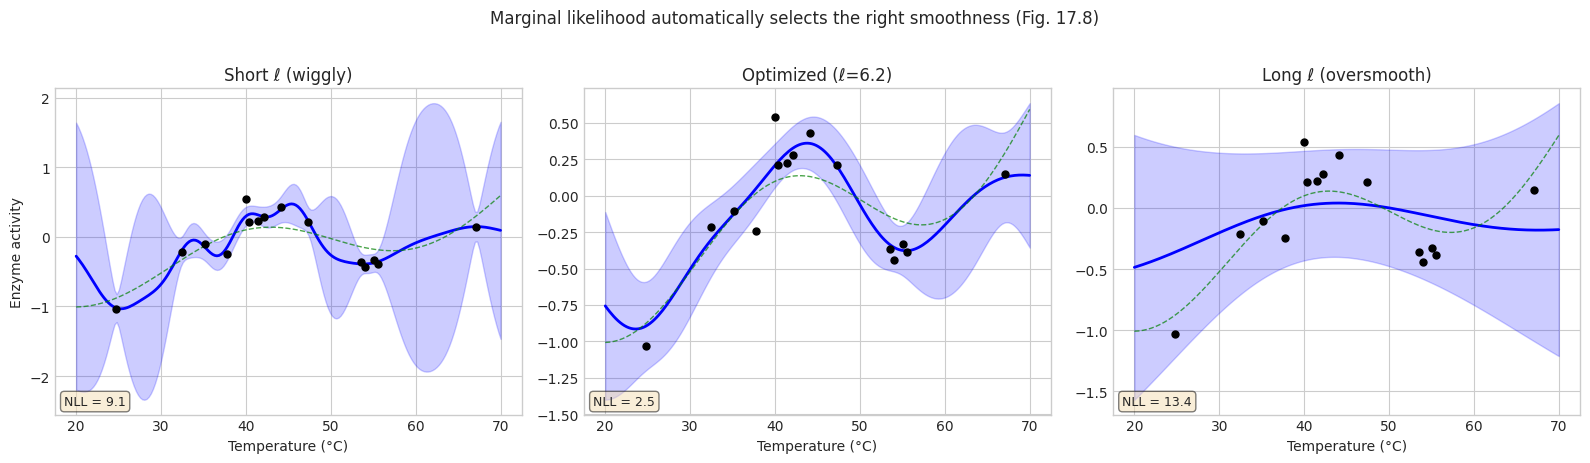

In [13]:
# Compare hand-picked vs optimized hyperparameters
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

configs = [
    (3.0, 1.0, 0.01, 'Short ℓ (wiggly)'),
    (ell_opt, sf2_opt, sy2_opt, f'Optimized (ℓ={ell_opt:.1f})'),
    (20.0, 1.0, 0.5, 'Long ℓ (oversmooth)'),
]

for ax, (ell_c, sf2_c, sy2_c, title) in zip(axes, configs):
    mu_c, var_c, _ = gp_posterior(X_train, y_train, X_test,
                                   length_scale=ell_c, signal_var=sf2_c, noise_var=sy2_c)
    std_c = np.sqrt(np.clip(var_c, 0, None))

    ax.fill_between(X_test.ravel(), mu_c - 2*std_c, mu_c + 2*std_c,
                     alpha=0.2, color='blue')
    ax.plot(X_test, mu_c, 'b-', linewidth=2)
    ax.plot(X_test, true_enzyme_activity(X_test), 'g--', linewidth=1, alpha=0.7)
    ax.plot(X_train, y_train, 'ko', markersize=5)
    ax.set_xlabel('Temperature (°C)')
    ax.set_title(title)
    nll = neg_log_marginal_likelihood(np.log([ell_c, sf2_c, sy2_c]), X_train, y_train)
    ax.text(0.02, 0.02, f'NLL = {nll:.1f}', transform=ax.transAxes, fontsize=9,
            verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[0].set_ylabel('Enzyme activity')
plt.suptitle('Marginal likelihood automatically selects the right smoothness (Fig. 17.8)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

### Marginal likelihood landscape and local minima (Fig. 17.9)

The log marginal likelihood is **not convex** — it can have multiple local optima. Each optimum corresponds to a different explanation of the data: e.g., "short length scale + low noise" (wiggly fit) vs. "long length scale + high noise" (smooth fit). With enough data, the true explanation wins.

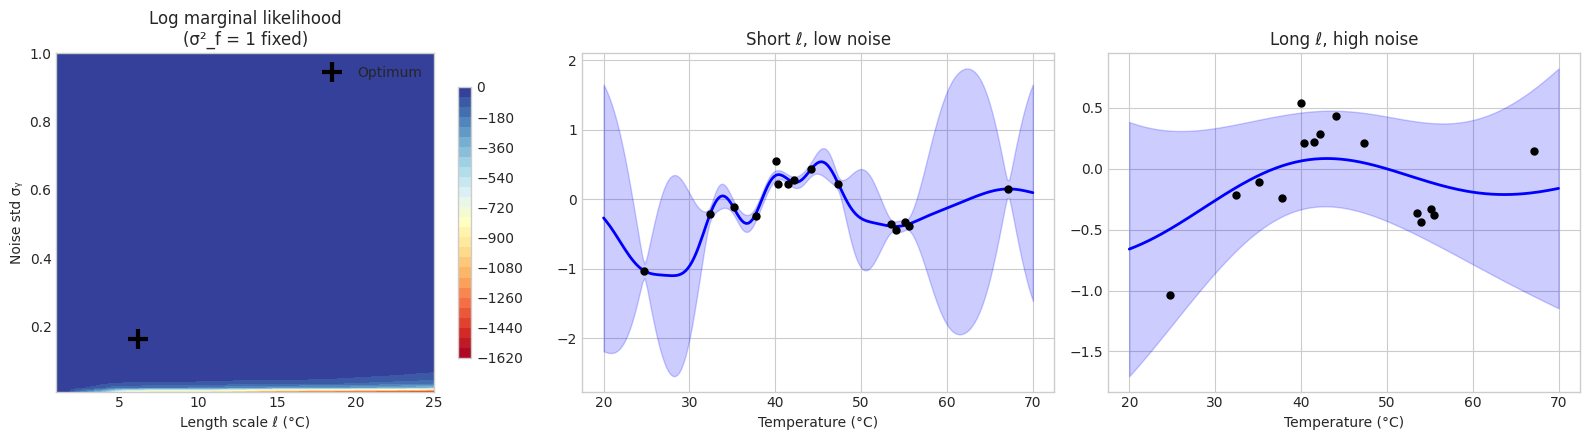

In [14]:
# Marginal likelihood surface over (ℓ, σ_y) with σ²_f fixed at 1
ell_grid = np.linspace(1, 25, 80)
sy_grid = np.linspace(0.01, 1.0, 80)
ELL, SY = np.meshgrid(ell_grid, sy_grid)
NLL_surface = np.zeros_like(ELL)

for i in range(len(sy_grid)):
    for j in range(len(ell_grid)):
        try:
            NLL_surface[i, j] = neg_log_marginal_likelihood(
                np.log([ELL[i,j], 1.0, SY[i,j]**2]), X_train, y_train)
        except:
            NLL_surface[i, j] = np.nan

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Log marginal likelihood surface
contour = axes[0].contourf(ELL, SY, -NLL_surface, levels=30, cmap='RdYlBu')
axes[0].set_xlabel('Length scale ℓ (°C)')
axes[0].set_ylabel('Noise std σᵧ')
axes[0].set_title('Log marginal likelihood\n(σ²_f = 1 fixed)')
plt.colorbar(contour, ax=axes[0], shrink=0.8)
axes[0].plot(ell_opt, np.sqrt(sy2_opt), 'k+', markersize=15, markeredgewidth=3, label='Optimum')
axes[0].legend()

# (b) & (c) Two different local optima
for ax, (ell_c, sy_c, title) in zip(axes[1:], [
    (3.0, 0.05, 'Short ℓ, low noise'),
    (18.0, 0.6, 'Long ℓ, high noise'),
]):
    mu_c, var_c, _ = gp_posterior(X_train, y_train, X_test,
                                   length_scale=ell_c, noise_var=sy_c**2)
    std_c = np.sqrt(np.clip(var_c, 0, None))
    ax.fill_between(X_test.ravel(), mu_c - 2*std_c, mu_c + 2*std_c, alpha=0.2, color='blue')
    ax.plot(X_test, mu_c, 'b-', linewidth=2)
    ax.plot(X_train, y_train, 'ko', markersize=5)
    ax.set_xlabel('Temperature (°C)')
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 7. Full Pipeline: Enzyme Activity Prediction

Putting it all together — we optimize the kernel hyperparameters via marginal likelihood, then make predictions with calibrated uncertainty.

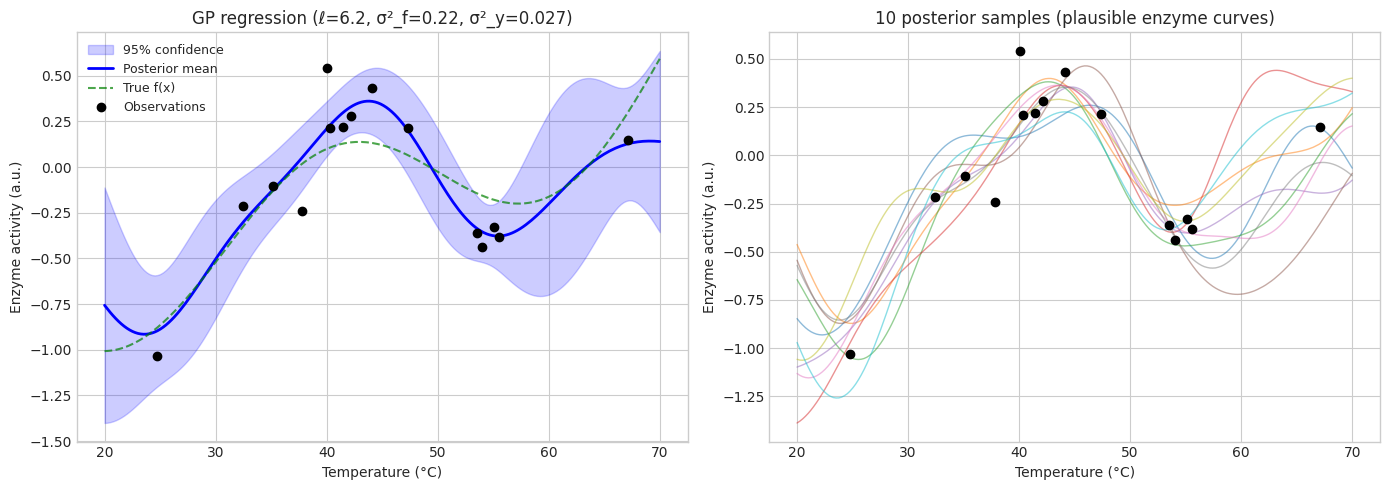

In [15]:
# Full GP pipeline with optimized hyperparameters
mu_opt, var_opt, cov_opt = gp_posterior(X_train, y_train, X_test,
                                         length_scale=ell_opt, signal_var=sf2_opt,
                                         noise_var=sy2_opt)
std_opt = np.sqrt(np.clip(var_opt, 0, None))

# Sample posterior functions
posterior_samples = np.random.multivariate_normal(mu_opt.ravel(),
                                                   cov_opt + 1e-8*np.eye(200), size=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Posterior mean + uncertainty
ax = axes[0]
ax.fill_between(X_test.ravel(), mu_opt - 2*std_opt, mu_opt + 2*std_opt,
                 alpha=0.2, color='blue', label='95% confidence')
ax.plot(X_test, mu_opt, 'b-', linewidth=2, label='Posterior mean')
ax.plot(X_test, true_enzyme_activity(X_test), 'g--', linewidth=1.5, alpha=0.7, label='True f(x)')
ax.plot(X_train, y_train, 'ko', markersize=6, label='Observations', zorder=5)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Enzyme activity (a.u.)')
ax.set_title(f'GP regression (ℓ={ell_opt:.1f}, σ²_f={sf2_opt:.2f}, σ²_y={sy2_opt:.3f})')
ax.legend(fontsize=9)

# (b) Posterior samples — each is a plausible enzyme activity curve
ax = axes[1]
for i, s in enumerate(posterior_samples):
    ax.plot(X_test, s, alpha=0.5, linewidth=1)
ax.plot(X_train, y_train, 'ko', markersize=6, zorder=5)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Enzyme activity (a.u.)')
ax.set_title('10 posterior samples (plausible enzyme curves)')

plt.tight_layout()
plt.show()